In [1]:
import pandas as pd
import numpy as np
import datetime as datetime
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as cx

In [2]:
df = pd.read_csv("data_output/avg_daily_stop_ridership.csv")
df.head()

/tmp/ipykernel_960/3319251006.py:1: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data_output/avg_daily_stop_ridership.csv")


,record_id,dataset_id,organization_name,service_name,stop_id,gtfs_stop_id,stop_name,stop_lat,stop_lon,avg_daily_boardings,avg_daily_alightings,avg_daily_ridership,avg_daily_method,start_date,end_date,day_type
0,2C7BF68BBE0E95F4,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900109,12th Street / Oakland City Center,37.803482,-122.271630,2120.0,2109.0,NaN,avg_from_daily,2024-10-01,2025-09-30,holiday
1,EFF7B5FEBF2CFE0F,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900109,12th Street / Oakland City Center,37.803482,-122.271630,2682.0,2603.0,NaN,avg_from_daily,2024-10-01,2025-09-30,saturday
2,BBCB1DF33E5F86E0,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900109,12th Street / Oakland City Center,37.803482,-122.271630,1817.0,1815.0,NaN,avg_from_daily,2024-10-01,2025-09-30,sunday
3,1216F8AEF13AC9AB,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900109,12th Street / Oakland City Center,37.803482,-122.271630,5477.0,5344.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday
4,00389318B6FA326D,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900209,19th Street / Oakland,37.808078,-122.268758,1980.0,1905.0,NaN,avg_from_daily,2024-10-01,2025-09-30,holiday


In [3]:
df.groupby(["organization_name", "start_date", "end_date", "day_type"], as_index=False, dropna=False).size()

,organization_name,start_date,end_date,day_type,size
0,City and County of San Francisco,2024-07-01,2025-06-30,weekday,18
1,City and County of San Francisco,2024-07-01,2025-06-30,weekend,18
2,City of Culver City,2025-07-14,2025-08-25,saturday,253
3,City of Culver City,2025-07-14,2025-08-25,sunday,254
4,City of Culver City,2025-07-14,2025-08-25,weekday,373
5,City of Fresno,2024-09-01,2025-08-31,holiday,1580
6,City of Fresno,2024-09-01,2025-08-31,weekday,1618
7,City of Fresno,2024-09-01,2025-08-31,weekend,1605
8,City of Santa Monica,2025-08-01,2025-11-30,saturday,684
9,City of Santa Monica,2025-08-01,2025-11-30,sunday,684


In [5]:
df = df.dropna(subset=["stop_lon", "stop_lat"]).copy()

t_df = df[df["day_type"].isin(["weekday", "all"])]

stops_gdf = gpd.GeoDataFrame(t_df,
                       geometry=gpd.points_from_xy(t_df["stop_lon"], t_df["stop_lat"]),
                       crs="EPSG:4326")

stops_gdf["plt_value"] = stops_gdf["avg_daily_boardings"].fillna(stops_gdf["avg_daily_ridership"])
stops_gdf.head()

,record_id,dataset_id,organization_name,service_name,stop_id,gtfs_stop_id,stop_name,stop_lat,stop_lon,avg_daily_boardings,avg_daily_alightings,avg_daily_ridership,avg_daily_method,start_date,end_date,day_type,geometry,plt_value
3,1216F8AEF13AC9AB,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900109,12th Street / Oakland City Center,37.803482,-122.271630,5477.0,5344.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.27163 37.80348),5477.0
7,977D746ED94E8732,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900209,19th Street / Oakland,37.808078,-122.268758,4894.0,4751.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.26876 37.80808),4894.0
11,13AFA78078BBD0C8,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900309,MacArthur,37.828803,-122.267105,3958.0,3880.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.26711 37.82880),3958.0
15,669F6C93320C3E84,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,901109,West Oakland,37.804888,-122.295151,3971.0,3652.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.29515 37.80489),3971.0
19,B818E78A112FA66E,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,901169,Embarcadero,37.792762,-122.397037,16218.0,18392.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.39704 37.79276),16218.0


In [6]:
stops_gdf.dtypes

record_id                 object
dataset_id                object
organization_name         object
service_name              object
stop_id                   object
gtfs_stop_id              object
stop_name                 object
stop_lat                 float64
stop_lon                 float64
avg_daily_boardings      float64
avg_daily_alightings     float64
avg_daily_ridership      float64
avg_daily_method          object
start_date                object
end_date                  object
day_type                  object
geometry                geometry
plt_value                float64
dtype: object

In [7]:
export_gdf = stops_gdf.copy()
export_gdf = export_gdf.rename(columns={"organization_name": "agency",
                                        "service_name": "service",
                                        "avg_daily_boardings": "boardings",
                                        "avg_daily_alightings": "alightings",
                                        "avg_daily_ridership": "ridership"})
export_gdf.to_file("stop_ridership_points.shp")

/tmp/ipykernel_960/3542277032.py:7: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  export_gdf.to_file("stop_ridership_points.shp")


In [8]:
export_gdf.head()

,record_id,dataset_id,agency,service,stop_id,gtfs_stop_id,stop_name,stop_lat,stop_lon,boardings,alightings,ridership,avg_daily_method,start_date,end_date,day_type,geometry
3,1216F8AEF13AC9AB,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900109,12th Street / Oakland City Center,37.803482,-122.271630,5477.0,5344.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.27163 37.80348)
7,977D746ED94E8732,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900209,19th Street / Oakland,37.808078,-122.268758,4894.0,4751.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.26876 37.80808)
11,13AFA78078BBD0C8,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,900309,MacArthur,37.828803,-122.267105,3958.0,3880.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.26711 37.82880)
15,669F6C93320C3E84,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,901109,West Oakland,37.804888,-122.295151,3971.0,3652.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.29515 37.80489)
19,B818E78A112FA66E,011CF30F49575609,San Francisco Bay Area Rapid Transit District,Bay Area Rapid Transit,NaN,901169,Embarcadero,37.792762,-122.397037,16218.0,18392.0,NaN,avg_from_daily,2024-10-01,2025-09-30,weekday,POINT (-122.39704 37.79276)


Text(0.5, 1.0, 'Avg Daily Ridership')

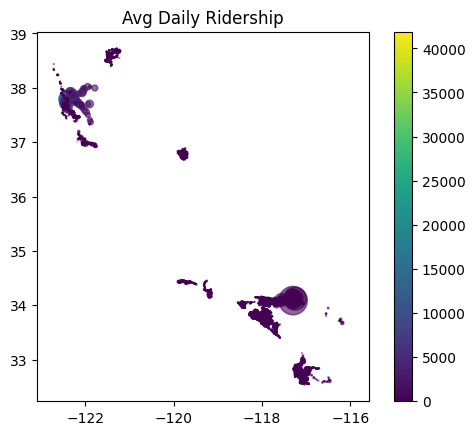

In [26]:
fig, ax = plt.subplots()

stops_gdf.plot(ax=ax,
         column="avg_daily_boardings",
         legend=True,
         markersize=gdf["avg_daily_boardings"].fillna(0)/100,
         alpha = 0.6)

ax.set_title("Avg Daily Ridership")

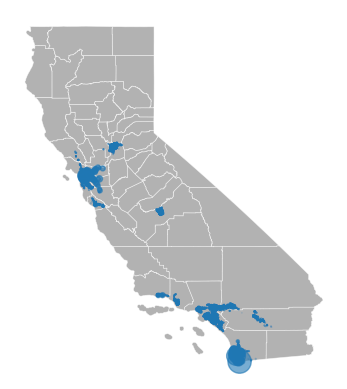

In [32]:
ca_gdf = gpd.read_file("shape/CA_Counties.shp")
crs={'init': 'epsg:4326'}
ca_gdf = ca_gdf.to_crs(stops_gdf.crs)
# print(ca_gdf.crs)

fig, ax = plt.subplots()

ca_gdf.plot(ax=ax, alpha=0.6, color="grey", edgecolor="white", linewidth=0.5)

stops_gdf.plot(ax=ax,
               markersize=stops_gdf["avg_daily_boardings"]/150,
               alpha=0.6)
ax.set_axis_off()

In [10]:
df.sort_values(by=["avg_daily_boardings", "avg_daily_alightings"], ascending=False)

,record_id,dataset_id,organization_name,service_name,stop_id,gtfs_stop_id,stop_name,stop_lat,stop_lon,avg_daily_boardings,avg_daily_alightings,avg_daily_ridership,avg_daily_method,start_date,end_date,day_type
46023,3CEFF00E8C7B8F9E,923349C0D2AC9D75,San Diego Metropolitan Transit System,San Diego Metropolitan Transit System,75000,75000,San Ysidro Station,32.544566,-117.029539,41894.0,40158.0,NaN,reported_avg_daily,2024-09-01,2025-01-25,weekday
46021,A11A54CC43E1D318,923349C0D2AC9D75,San Diego Metropolitan Transit System,San Diego Metropolitan Transit System,75000,75000,San Ysidro Station,32.544566,-117.029539,27424.0,27443.0,NaN,reported_avg_daily,2024-09-01,2025-01-25,saturday
46323,F0CBB11710C2C59A,923349C0D2AC9D75,San Diego Metropolitan Transit System,San Diego Metropolitan Transit System,75103,75103,12th & Imperial Station,32.705785,-117.153326,27175.0,14041.0,NaN,reported_avg_daily,2024-09-01,2025-01-25,weekday
46022,564F11D66F91E94E,923349C0D2AC9D75,San Diego Metropolitan Transit System,San Diego Metropolitan Transit System,75000,75000,San Ysidro Station,32.544566,-117.029539,25545.0,20311.0,NaN,reported_avg_daily,2024-09-01,2025-01-25,sunday
46321,F1777D26FD22AA54,923349C0D2AC9D75,San Diego Metropolitan Transit System,San Diego Metropolitan Transit System,75103,75103,12th & Imperial Station,32.705785,-117.153326,17836.0,9009.0,NaN,reported_avg_daily,2024-09-01,2025-01-25,saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48490,27A97DB437D5FE20,D3642CDF7FD75B27,Peninsula Corridor Joint Powers Board,Caltrain,NaN,sunnyvale,Sunnyvale,37.378934,-122.031500,NaN,NaN,2224.0,reported_avg_daily,2025-07-01,2025-07-31,weekday
48491,5FB46C85F6B8E6A1,D3642CDF7FD75B27,Peninsula Corridor Joint Powers Board,Caltrain,NaN,tamien,Tamien,37.312690,-121.884700,NaN,NaN,8.0,reported_avg_daily,2025-07-01,2025-07-31,holiday
48492,4417F02F7C40AAF4,D3642CDF7FD75B27,Peninsula Corridor Joint Powers Board,Caltrain,NaN,tamien,Tamien,37.312690,-121.884700,NaN,NaN,9.0,reported_avg_daily,2025-07-01,2025-07-31,saturday
48493,055825EE982E02BC,D3642CDF7FD75B27,Peninsula Corridor Joint Powers Board,Caltrain,NaN,tamien,Tamien,37.312690,-121.884700,NaN,NaN,9.0,reported_avg_daily,2025-07-01,2025-07-31,sunday
